# Parte 2: Modelagem Preditiva

## Alunos: 
- <font color="blue">Hugo Samuel;<font>
- <font color="red">Vítor Belo<font>;
- Vinícius Fernandes.

<font color="blue">Nesta segunda etapa do projeto, o foco transita da análise estatística e processamento de sinais para o campo do Aprendizado de Máquina. O objetivo é desenvolver e comparar diferentes modelos de classificação capazes de diagnosticar automaticamente o estado operacional do grupo motopropulsor baseando-se na telemetria.

<font color="blue">Para abranger diferentes abordagens de reconhecimento de padrões, o trabalho avalia quatro algoritmos distintos, cada um sob a responsabilidade de um integrante da equipe:
- **Regressão Logística**
- **Support Vector Machine (SVM)**
- **K-Nearest Neighbors (KNN)**

<font color="blue">Esta seção avalia o modelo sob a visão da competição em que a equipe participa, convertendo os dados do algoritmo em impacto direto na pontuação da **SAE Brasil AeroDesign (Classe Micro)**.<font>

In [1]:
# Importações necessárias para a Parte 2 (Machine Learning)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
import seaborn as sns
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

# Regressão Logística
---

## 1. Extração de Características 

<font color="blue">A extração de características ocorreu mediante uma técnica de janelamento de 50 amostras. Esta abordagem evita a correlação excessiva entre exemplos parecidos no conjunto de dados. Através disso, extraíram-se medidas estatísticas e métricas de domínio temporal de cada janela.<font>

In [2]:
def transitory_stacionary(df_i):
    # Substitua pelo seu código real que extrai o regime permanente, caso necessário.
    return None, df_i.copy(), None

def extrair_features_por_janela(df, tamanho_janela=50, passo=50):
    amostras = []
    # Ajustado o range para garantir que o processamento respeite o passo definido
    for i in range(0, len(df) - tamanho_janela + 1, passo):
        bloco = df.iloc[i : i + tamanho_janela]
        
        features = {}
        for col in bloco.columns:
            valores = bloco[col].dropna()
            if valores.empty:
                continue
            
            # Features estatísticas básicas
            features[f"{col}_Media"] = valores.mean()
            features[f"{col}_Mediana"] = valores.median()
            features[f"{col}_DesvioPadrao"] = valores.std()
            features[f"{col}_Skew"] = valores.skew()
            features[f"{col}_Kurtosis"] = valores.kurt()
            
            # Features avançadas
            q75, q25 = np.percentile(valores, [75 ,25])
            features[f"{col}_IQR"] = q75 - q25 
            
            rms = np.sqrt(np.mean(valores**2))
            features[f"{col}_RMS"] = rms
            features[f"{col}_Energia"] = np.sum(valores**2)
            
            # Features vitais para detecção de anomalias mecânicas
            val_max = valores.max()
            val_min = valores.min()
            features[f"{col}_PicoAPico"] = val_max - val_min 
            features[f"{col}_FatorCrista"] = np.max(np.abs(valores)) / rms if rms > 0 else 0
            
        amostras.append(pd.Series(features))
        
    return amostras

## 2. Preparação e Estruturação do Dataset

<font color="blue">Nesta etapa, o algoritmo extrai as pastas com os ensaios originais coletados. O regime permanente é extraído, e em seguida, o janelamento é aplicado para criar a base que alimentará os algoritmos de *Machine Learning*. <font>

In [3]:
# PREPARAÇÃO DOS DADOS
from pathlib import Path
thisFolder = Path.cwd()
dataFolder = os.path.join(thisFolder, "dados")

# Seleciona as pastas de cada operação (operação normal e falhas)
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

pastas = [
    normalFolder,
    desbalanceadaFolder,
    quebradaFolder,
    invertidaFolder
]

lista_arquivos_com_classe = []

for p in pastas:
    if os.path.exists(p):
        for arquivo in os.listdir(p):
            if arquivo.endswith(".xlsx"):
                nome_f = arquivo.lower()
                classe = 4
                if "normal" in nome_f: classe = 0
                elif "quebrada" in nome_f: classe = 1
                elif "desbalanceada" in nome_f: classe = 2
                elif "invertida" in nome_f: classe = 3
                
                if classe != 4:
                    lista_arquivos_com_classe.append((os.path.join(p, arquivo), classe))

# Divisão por arquivos inteiros
train_files, test_files = train_test_split(
    lista_arquivos_com_classe, 
    test_size=0.2, 
    random_state=42, 
    stratify=[c for _, c in lista_arquivos_com_classe]
)

def processar_arquivos(lista_arquivos):
    dados = []
    for caminho, classe in lista_arquivos:
        try:
            df_i = pd.read_excel(caminho)
            colunas_proibidas = [c for c in df_i.columns if any(s in c.lower() for s in ['potencia', 'rpm'])]
            df_i = df_i.drop(columns=colunas_proibidas, errors="ignore")
            
            _, df_1, _ = transitory_stacionary(df_i)
            amostras_janeladas = extrair_features_por_janela(df_1, tamanho_janela=50, passo=50)
            
            for linha in amostras_janeladas:
                linha["Classe"] = classe
                dados.append(linha)
        except Exception:
            pass
            
    return pd.DataFrame(dados).fillna(0)

df_train = processar_arquivos(train_files)
df_test = processar_arquivos(test_files)

X_train, y_train = df_train.drop(columns=["Classe"]), df_train["Classe"]
X_test, y_test = df_test.drop(columns=["Classe"]), df_test["Classe"]
print(f"Dataset final construído! Amostras de Treino: {len(X_train)} | Teste: {len(X_test)}")

Dataset final construído! Amostras de Treino: 141 | Teste: 49


## 3. Treinamento e Otimização de Limiar

<font color="blue">Os dados foram divididos em 80% para treino e 20% para teste. O modelo baseou-se em um *Pipeline* contendo o `RobustScaler` e a função `PolynomialFeatures`.

<font color="blue">Em vez de adotar o limiar de decisão padrão de 50%, implementou-se uma otimização por custo de erro. O algoritmo avalia os impactos dos Falsos Positivos e Falsos Negativos e determina a probabilidade ótima para acionar a manutenção preditiva. <font>

In [4]:

# TREINO DO MODELO 
modelo = Pipeline([
    ("scaler", RobustScaler()), 
    ("poly", PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)), 
    ("logreg", LogisticRegression(max_iter=5000, class_weight='balanced', C=10, solver='lbfgs', random_state=42))
])

modelo.fit(X_train, y_train)

# Extração das probabilidades brutas no conjunto de teste
probs = modelo.predict_proba(X_test)
prob_falha = np.sum(probs[:, 1:], axis=1)

limiares = np.linspace(0.1, 0.9, 50)
custos = []
melhor_tau = 0.5
menor_custo = float('inf')
pontos_maximos = 277
pts_desbalanceada = 138

# Testa todos os limiares para minimizar a perda de pontos na competição SAE
for tau in limiares:
    preds_tau = np.where(prob_falha >= tau, np.argmax(probs[:, 1:], axis=1) + 1, 0)
    
    pontos_cenario = 0
    for real, pred in zip(y_test, preds_tau):
        if pred == 0:
            if real == 0: pontos_cenario += pontos_maximos
            elif real == 1: pontos_cenario += 0
            elif real == 2: pontos_cenario += pts_desbalanceada
            elif real == 3: pontos_cenario += 0
        else: 
            if real == 0: pontos_cenario += 0 
            else: pontos_cenario += pontos_maximos
            
    # Custo Médio (Pontos perdidos por bateria)
    custo_total_perdido = (len(y_test) * pontos_maximos) - pontos_cenario
    custo_medio = custo_total_perdido / len(y_test) if len(y_test) > 0 else 0
    
    custos.append(custo_medio)
    
    if custo_medio < menor_custo:
        menor_custo = custo_medio
        melhor_tau = tau

print(f"-> Limiar (Threshold) Otimizado por Custo: {melhor_tau:.2f}\n")

# Aplicação final utilizando o limiar ótimo
y_pred = np.where(prob_falha >= melhor_tau, np.argmax(probs[:, 1:], axis=1) + 1, 0)

nomes_classes = ["Normal", "Quebrada", "Desbalanceada", "Invertida"]
classes_presentes = np.unique(y_test)
nomes_presentes = [nomes_classes[int(c)] for c in classes_presentes]

relatorio_dicionario = classification_report(y_test, y_pred, target_names=nomes_presentes, output_dict=True)
tabela_metricas = pd.DataFrame(relatorio_dicionario).transpose()

print("="*60)
print("   TABELA DE MÉTRICAS DE CLASSIFICAÇÃO (POR FALHA)")
print("="*60)
print(tabela_metricas[['precision', 'recall', 'f1-score', 'support']].round(3))
print("="*60)
print(f"ACURÁCIA GLOBAL DO MODELO: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("="*60 + "\n")

-> Limiar (Threshold) Otimizado por Custo: 0.10

   TABELA DE MÉTRICAS DE CLASSIFICAÇÃO (POR FALHA)
               precision  recall  f1-score  support
Normal             0.500   0.500     0.500   12.000
Quebrada           0.467   0.700     0.560   10.000
Desbalanceada      0.833   0.667     0.741   15.000
Invertida          1.000   0.833     0.909   12.000
accuracy           0.673   0.673     0.673    0.673
macro avg          0.700   0.675     0.677   49.000
weighted avg       0.718   0.673     0.686   49.000
ACURÁCIA GLOBAL DO MODELO: 67.35%



## 4. Análise de Risco e Impacto na Pontuação SAE AeroDesign

<font color="blue">Esta seção avalia os benefícios diretos do uso da classificação de Machine Learning (agora ajustada em prol da equipe) comparado com a decisão de voar às cegas.<font>

In [5]:

# CÁLCULO de Impacto nos Pontos 
pontos_sem_pesquisa, pontos_com_pesquisa = 0, 0

for real, pred in zip(y_test, y_pred):
    # Cenário 1: SEM pesquisa
    if real == 0: pontos_sem_pesquisa += pontos_maximos
    elif real == 1: pontos_sem_pesquisa += 0
    elif real == 2: pontos_sem_pesquisa += pts_desbalanceada
    elif real == 3: pontos_sem_pesquisa += 0
    
    # Cenário 2: COM pesquisa (Limiar Otimizado)
    if pred == 0:
        if real == 0: pontos_com_pesquisa += pontos_maximos
        elif real == 1: pontos_com_pesquisa += 0
        elif real == 2: pontos_com_pesquisa += pts_desbalanceada
        elif real == 3: pontos_com_pesquisa += 0
    else: 
        if real == 0: pontos_com_pesquisa += 0 
        else: pontos_com_pesquisa += pontos_maximos 

media_sem_pesquisa = pontos_sem_pesquisa / len(y_test) if len(y_test) > 0 else 0
media_com_pesquisa = pontos_com_pesquisa / len(y_test) if len(y_test) > 0 else 0
media_ideal = pontos_maximos

print("="*50)
print(" IMPACTO NA PONTUAÇÃO - SAE BRASIL AERODESIGN")
print("="*50)
print(f"Cenário 1 : Média de {media_sem_pesquisa:.1f} pontos por tentativa.")
print(f"Cenário 2 : Média de {media_com_pesquisa:.1f} pontos por tentativa.")
print(f"\n-> Com essa pesquisa, salva-se em média {media_com_pesquisa - media_sem_pesquisa:.1f} pontos por rodada!")
print("="*50 + "\n")

 IMPACTO NA PONTUAÇÃO - SAE BRASIL AERODESIGN
Cenário 1 : Média de 110.1 pontos por tentativa.
Cenário 2 : Média de 220.4 pontos por tentativa.

-> Com essa pesquisa, salva-se em média 110.3 pontos por rodada!



## 5. Visualização dos Resultados

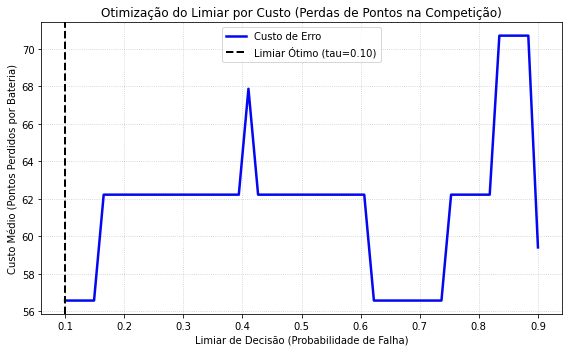

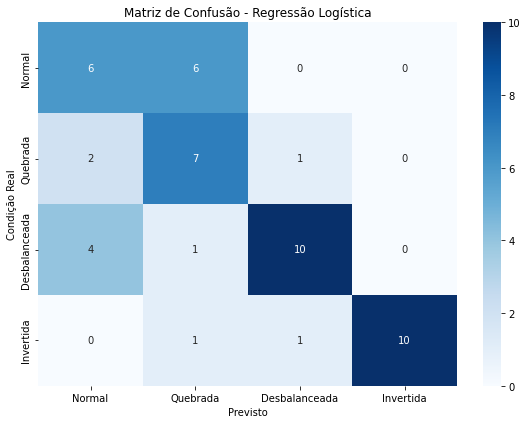

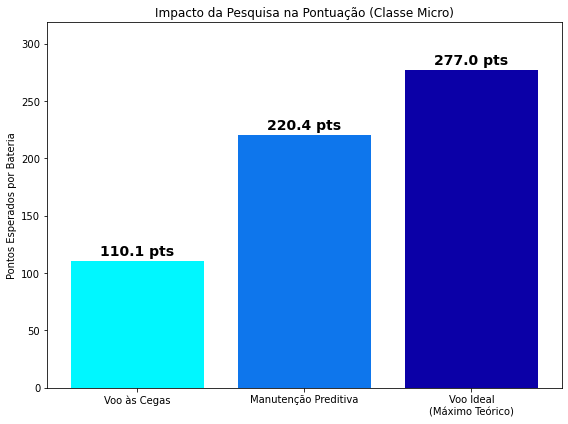

In [6]:

# PLOTAGEM DE RESULTADOS GRÁFICOS

# Gráfico 1: Escolha do limiar por custo
plt.figure(figsize=(8, 5))
plt.plot(limiares, custos, color="#0408f1", linewidth=2.5, label='Custo de Erro')
plt.axvline(melhor_tau, color='black', linestyle='--', linewidth=2, label=f'Limiar Ótimo (tau={melhor_tau:.2f})')
plt.title("Otimização do Limiar por Custo (Perdas de Pontos na Competição)")
plt.xlabel("Limiar de Decisão (Probabilidade de Falha)")
plt.ylabel("Custo Médio (Pontos Perdidos por Bateria)") 
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

# Gráfico 2: Matriz de Confusão
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=nomes_presentes, yticklabels=nomes_presentes)
plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Previsto")
plt.ylabel("Condição Real")
plt.tight_layout()
plt.show()

# Gráfico 3: Impacto de Barras
plt.figure(figsize=(8, 6))
labels = ['Voo às Cegas\n', 'Manutenção Preditiva', 'Voo Ideal\n(Máximo Teórico)']
valores = [media_sem_pesquisa, media_com_pesquisa, media_ideal]
cores = ["#00f7ff", "#0e76ec", "#0b00a7"] 

barras = plt.bar(labels, valores, color=cores)
plt.ylim(0, pontos_maximos * 1.15)
plt.ylabel("Pontos Esperados por Bateria")
plt.title("Impacto da Pesquisa na Pontuação (Classe Micro)")

for b in barras:
    plt.annotate(f"{b.get_height():.1f} pts", 
                 xy=(b.get_x() + b.get_width() / 2, b.get_height()),
                 xytext=(0, 3), textcoords="offset points", 
                 ha='center', va='bottom', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()


# Método SVM

<font color="red">As seções abaixo apresentam a metodologia utilizada para a confecção do algoritmo de treino SVM.<font>

---

## 1. Imports

<font color="red">A seção abaixo importa todas as bibliotecas utilizadas para o método SVM.<font>

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import statistics as st
from sklearn.model_selection import GridSearchCV
from pathlib import Path

## 2. Diretórios
<font color="red">Abaixo há a alocação dos diretórios de interesse em variáveis.<font>

In [8]:
thisFolder = Path.cwd() # os.path.dirname(__file__)
dataFolder = os.path.join(thisFolder, "dados")

# Seleciona as pastas de cada operação (operação normal e falhas)
desbalanceadaFolder = os.path.join(dataFolder, "helice_desbalanceada")
quebradaFolder = os.path.join(dataFolder, "helice_quebrada")
normalFolder = os.path.join(dataFolder, "normal")
invertidaFolder = os.path.join(dataFolder, "rotacao_invertida")

folders = {
    "normal": normalFolder,
    "desbalanceada": desbalanceadaFolder,
    "quebrada": quebradaFolder,
    "invertida": invertidaFolder
}



## 3. Segmentação das fases de operação
<font color="red">A seção abaixo realiza a segmentação do dataframe em fases de transitório e fases estacionárias, como citado no Trabalho 1. Atualmente o interesse é avaliar apenas a fase de regime permanente, portanto, os transitórios foram desconsiderados na obtenção de medidas estatísticas para o treinamento do modelo.<font>

In [9]:
def transitory_stacionary(df):
    
    # Adquire a localização em índice da coluna de "Corrente_A" do dataframe utilizado como argumento
    # Há a soma "+ 1" pois, para a indexação em cada linha através do da função "itertuples()" do pandas
    loc_i = df.columns.get_loc("Corrente_A") + 1

    # Obtém os intervalos em que estão localizados 30% e 70% dos valores de corrente armazenados
    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)

    # Cria um novo dataframe cujos valores são aqueles entre q1 e q3, ou seja, 40% dos dados centrais
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    # "Flag" criada para indicar que o ponto que termina o transitório inicial e inicia a seção do regime permanente já foi identificado
    flag_stac = False

    # "Flag" para indicar que o ponto que termina o regime permanente e inicia o transitório final ainda não foi identificado
    flag_transitory_1 = True

    # Valor em que o transitório 2 será armazenado
    transitory_2 = None

    # Média do dataframe com os 40% dos dados centrais
    mean = df_40["Corrente_A"].mean()
    
    # Para cada linha (row) no dataframe, numerando as iterações pela variável "idx"...
    for idx, row in enumerate(df.itertuples()):

        # Verifica se o valor de corrente está entre 99% e 130% da média, além de verificar se flag_transitory_1 == True
        if ((np.abs(row[loc_i]) >= 0.99*mean) & (np.abs(row[loc_i]) <= 1.3*mean) & flag_transitory_1):
            
            # O valor de índice atual somado a 10 posições é armazenado na variável "transitory_1"
            transitory_1 = idx + 12

            # As flags são atualizadas
            flag_stac = True
            flag_transitory_1 = False

        # Se a flag_stac == True... 
        if flag_stac:

            # Realiza a verificação se o valor atual de corrente está entre 30 e 82% da média
            if ((np.abs(row[loc_i]) <= 0.82*mean) & (np.abs(row[loc_i]) >= 0.3*mean)):
                
                # Armazena o índice atual subtraído de 8 posições na variável transitory_2
                transitory_2 = idx - 8
                break

    # O dataframe referente ao transitório inicial é definido
    df_0 = df.iloc[:transitory_1]

    # Se for for identificado o transitório final...
    if transitory_2 != None:

        # O dataframe do regime permanente é definido entre as duas posições armazenadas anteriormente
        df_1 = df.iloc[transitory_1:transitory_2]

        # O dataframe do transitório final é definido
        df_2 = df.iloc[transitory_2:]
    
    # Caso contrário...
    else:
        
        # O dataframe do regime permanente é definido entre a posição do "transitory_1" até o final do dataframe
        df_1 = df.iloc[transitory_1:]
        # O dataframe do transitório final é definido como "None" por não ter sido identificado
        df_2 = None

    return df_0, df_1, df_2


## 4. Função para treino do modelo
<font color="red">A função abaixo foi elaborada para realizar o treinamento do modelo com base nos dados coletados. Devido ao baixo número de dados coletados, optou-se por utilizar 40% dos dados para teste, ao invés do número estipulado inicialmente (30%). Dessa forma, foi possível ter uma maior representação dos resultados sem interferir significativamente na etapa de treinamento.<font>

<font color="red">Optou-se por realizar a normalização dos dados no Pipeline, evitando que haja conflito de dimensões ao verificar a relação das variáveis. Dessa forma, os valores de entrada apresentam média 0 e variância unitária.<font>

<font color="red">Utilizou-se o Kernel RBF com peso de classes balanceado<font>

In [10]:
def trainModel(dados_extraidos):
    df = pd.DataFrame(dados_extraidos)

    X = df.drop('condicao', axis=1) # Remoção da condição observada da entrada para evitar vazamento de dados
    y = df['condicao'] # Alocação da condição apenas na variável de saída

    # Segmentando dados de treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
    print(X_train)

    # Definição do pipeline a ser utilizado
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
    ])

    # Definição dos vetores de parâmetros. Os parâmetros C e gamma serão ajustados com base nos valores incorporados abaixo
    parametros_busca = {
        'svm__C': [0.1, 1, 10, 100, 1000],
        'svm__gamma': ['scale', 'auto', 0.01, 0.1, 1]
    }
    
    # Utilização da função GridSearchCV para realizar validação cruzada a partir do pipeline definido. A validação cruzada ...
    # irá retornar os valores de parâmetros que resultaram em uma maior acurácia média nos resultados.
    grid_search = GridSearchCV(pipeline, parametros_busca, cv=3, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)
    print("Melhores hiperparâmetros:", grid_search.best_params_)
    print("Melhor desempenho médio na validação:", grid_search.best_score_)

    # Seleciona o melhor modelo
    melhor_modelo = grid_search.best_estimator_

    # Testa esse modelo com base nos dados de teste
    y_pred = melhor_modelo.predict(X_test)

    print("\n=== Relatório do modelo após validaçcão cruzada ===")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=melhor_modelo.classes_)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=melhor_modelo.classes_, yticklabels=melhor_modelo.classes_)
    plt.title('Matriz de Confusão')
    plt.ylabel('Condição Real')
    plt.xlabel('Condição Prevista')
    plt.show()

    return melhor_modelo

## 5. Algoritmo consolidado
<font color="red">Esse algoritmo aproveita uma iteração elaborada no primeiro trabalho, mas inserindo uma etapa de janelamento, que subdivide os dataframes dos ensaios de 50 em 50 dados. Isso faz com que seja possível aproveitar uma maior quantidade de dados que serão subdivididos em treino e teste. Utilizou-se uma restrição que garante que a janela de dados tenha, no mínimo, 10 dados.

<font color="red">Dentre todos os parâmetros estatísticos apresentados no Trabalho 1, optou-se por utilizar média, desvio padrão, assimetria e curtose na avaliação do modelo. Dessa forma não há dados em excesso, aproveitando as métricas que representam satisfatóriamente o comportamento do sistema.<font>



================== normal ==================



================== desbalanceada ==================



================== quebrada ==================



================== invertida ==================

     Celula1_Kgf_mean  Celula1_Kgf_std  Celula1_Kgf_skew  \
70        -538.180000         2.647216          0.188757   
26        -663.300000         3.604136         -0.748682   
28        -641.140000         2.871464          0.103101   
99        -524.080000         3.403719          0.158641   
11        -642.900000         2.101991         -0.041201   
..                ...              ...               ...   
65        -784.420000       205.178975         -0.115068   
60        -901.780000       132.258913          0.124868   
33        -593.172414         3.295765          0.246948   
87        -538.840000         5.104460          0.027967   
113        748.314286         3.224643          0.095425   

     Celula1_Kgf_kurtosis  Celula1_Kgf_rms  Celula2_Kgf_mean  Celula2_Kgf_s

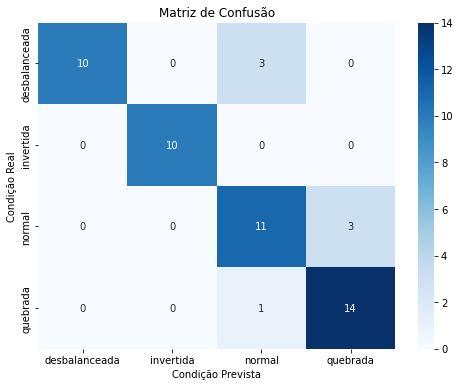

In [11]:
dados_extraidos = []

for fold in folders: # Para cada chave definida no dicionário "folders" definido anteriormente...

    # Criação de listas vazias.
    df0s = []   # Lista de dataframes do transitório inicial
    df1s = []   # Lista de dataframes do regime permanente
    df2s = []   # Lista de dataframes do transitório final

    tr1_tot_qty = 0 # Quantidade de dados no transitório inicial
    tr2_tot_qty = 0 # Quantidade de dados no regime permanente
    regime_tot_qty = 0  # Quantidade de pontos no transitório final

    print("")
    print("")
    print("==================", fold, "==================")   # Imprime o título da operação atual (normal, desbalanceada, quebrada ou invertida)
    print("")
    
    # Armazena todos os diretórios presentes na pasta atual em uma lista chamada "files_temp"
    files_temp = [os.path.join(folders[fold], x) for x in os.listdir(folders[fold]) if x.endswith(".xlsx")] 

    # Cria uma lista com todos os DataFrames contidos na pasta atual
    dfs = [pd.read_excel(f) for f in files_temp]

    # Acessa cada DataFrame "df_i" da lista de DataFrames da pasta atual, numerando a partir da variável "i"
    for i, df_i in enumerate(dfs):

        # Remoção dos parâmetros não utilizados na análise
        
        df_i = df_i.drop(columns="RPM")
        df_i = df_i.drop(columns="Potencia_W")
    
        df_0, df_1, df_2 = transitory_stacionary(df_i)  # Segmenta o dataframe "df_i" nos dataframes de transitórios (df_0 e df_2) e regime permanente (df_1)

        # Realiza o somatório da quantidade de dados presentes em cada planilha de uma operação
        tr1_tot_qty = len(df_0)
        regime_tot_qty = len(df_1)
        tr2_tot_qty = len(df_2)

        df_1.dropna()
        windowLenght = 50
        if not df_1.empty:
            for inicio in range(0, len(df_1), windowLenght):
                
                janela = df_1.iloc[inicio : inicio + windowLenght]
                
                if len(janela) >= 10:
                    estatisticas_arquivo = {'condicao': fold}
                    
                    for coluna in df_1.columns:
                        
                        estatisticas_arquivo[f'{coluna}_mean'] = janela[coluna].mean()
                        estatisticas_arquivo[f'{coluna}_std'] = janela[coluna].std()
                        #estatisticas_arquivo[f'{coluna}_max'] = df_1[coluna].max()
                        #estatisticas_arquivo[f'{coluna}_min'] = df_1[coluna].min()
                        #estatisticas_arquivo[f'{coluna}_median'] = df_1[coluna].median()
                        estatisticas_arquivo[f'{coluna}_skew'] = janela[coluna].skew()
                        estatisticas_arquivo[f'{coluna}_kurtosis'] = janela[coluna].kurtosis()
                        estatisticas_arquivo[f'{coluna}_rms'] = np.sqrt(np.mean(janela[coluna]**2))
                    
                    dados_extraidos.append(estatisticas_arquivo)

modelo = trainModel(dados_extraidos)

# Treinamento do classificador KNN

A estratégia adotada consiste em converter cada série em amostras estruturadas por meio de janelamento, extração de características estatísticas e posterior modelagem supervisionada.

A pipeline é composta por quatro etapas principais:
- pré-processamento dos sinais e isolamento do regime permanente;
- segmentação temporal em janelas de 50 amostras para reduzir a correlação entre observações consecutivas;
- extração de descritores estatísticos e energéticos, como média, desvio padrão, assimetria, curtose e RMS, que capturam a dinâmica local do sinal;
- treinamento e validação do classificador, incluindo normalização dos atributos e otimização de hiperparâmetros por meio de busca em grade com validação cruzada.

O objetivo é transformar dados brutos de telemetria em características discriminativas, de modo que o modelo consiga distinguir, com maior robustez, diferentes estados de funcionamento do sistema.

## 1. Caminhos dos dados

Cada subpasta representa uma classe do problema.

In [12]:
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# Ajuste este caminho somente se o notebook for executado fora da pasta do projeto.
THIS_FOLDER = Path.cwd()

if not (THIS_FOLDER / "dados").exists() and (THIS_FOLDER / "knn" / "dados").exists():
    THIS_FOLDER = THIS_FOLDER / "knn"

DATA_FOLDER = THIS_FOLDER / "dados"

FOLDERS = {
    "normal": DATA_FOLDER / "normal",
    "desbalanceada": DATA_FOLDER / "helice_desbalanceada",
    "quebrada": DATA_FOLDER / "helice_quebrada",
    "invertida": DATA_FOLDER / "rotacao_invertida",
}

DROP_COLUMNS = ["RPM", "Potencia_W"]
MODEL_PATH = THIS_FOLDER / "KNN_bestModel.pkl"
CONFUSION_MATRIX_PATH = THIS_FOLDER / "KNN_confusion_matrix.png"
ARTICLE_CONFUSION_MATRIX_PATH = THIS_FOLDER / "artigo" / "imgs" / "knn_confusion_matrix.png"
FEATURES_PATH = THIS_FOLDER / "KNN_features.csv"
FEATURE_NAMES_PATH = THIS_FOLDER / "KNN_feature_names.txt"
METRICS_TXT_PATH = THIS_FOLDER / "KNN_metrics.txt"
METRICS_CSV_PATH = THIS_FOLDER / "KNN_metrics.csv"

print(f"Pasta base: {THIS_FOLDER}")
print(f"Pasta de dados: {DATA_FOLDER}")

Pasta base: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2
Pasta de dados: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\dados


## 1. Extração de características

Nesta etapa, os sinais são lidos a partir dos arquivos de cada condição operacional e submetidos a um processo de segmentação. O primeiro passo consiste na identificação do regime permanente, isto é, da porção do sinal em que o comportamento dinâmico já se estabilizou, excluindo transientes iniciais e eventos de transição.

As métricas extraídas funcionam como descritores de baixa dimensionalidade, permitindo que o classificador opere sobre padrões robustos em vez de sobre séries brutas e altamente correlacionadas.

Em seguida, aplica-se a técnica de janelamento, na qual o sinal é dividido em blocos curtos de tamanho fixo. Cada janela é então resumida por um conjunto de características estatísticas que descrevem sua forma, dispersão e energia. Esse procedimento é fundamental para reduzir o ruído temporal e gerar representações mais adequadas ao modelo de classificação.

In [13]:
def transitory_stacionary(df):
    loc_i = df.columns.get_loc("Corrente_A") + 1

    q1 = df["Corrente_A"].quantile(0.30)
    q3 = df["Corrente_A"].quantile(0.70)
    df_40 = df[(df["Corrente_A"] >= q1) & (df["Corrente_A"] <= q3)]

    flag_stac = False
    flag_transitory_1 = True
    transitory_1 = 0
    transitory_2 = None
    mean = df_40["Corrente_A"].mean()

    for idx, row in enumerate(df.itertuples()):
        corrente = abs(row[loc_i])

        if 0.99 * mean <= corrente <= 1.3 * mean and flag_transitory_1:
            transitory_1 = idx + 12
            flag_stac = True
            flag_transitory_1 = False

        if flag_stac and 0.3 * mean <= corrente <= 0.82 * mean:
            transitory_2 = idx - 8
            break

    df_0 = df.iloc[:transitory_1]

    if transitory_2 is not None:
        df_1 = df.iloc[transitory_1:transitory_2]
        df_2 = df.iloc[transitory_2:]
    else:
        df_1 = df.iloc[transitory_1:]
        df_2 = None

    return df_0, df_1, df_2

In [14]:
def window_statistics(df, condicao):
    row = {"condicao": condicao}

    for coluna in df.columns:
        valores = df[coluna].dropna()

        if valores.empty:
            continue

        row[f"{coluna}_mean"] = valores.mean()
        row[f"{coluna}_std"] = valores.std()
        row[f"{coluna}_skew"] = valores.skew()
        row[f"{coluna}_kurtosis"] = valores.kurtosis()
        row[f"{coluna}_rms"] = np.sqrt(np.mean(valores**2))

    return row


def extract_features(window_length=50, min_window_length=10):
    dados_extraidos = []

    for condicao, folder in FOLDERS.items():
        files = [folder / name for name in os.listdir(folder) if name.endswith(".xlsx")]

        print(f"\n================== {condicao} ==================")
        print(f"Arquivos encontrados: {len(files)}")

        for file_path in files:
            df = pd.read_excel(file_path)
            df = df.drop(columns=DROP_COLUMNS, errors="ignore")

            _, df_regime, _ = transitory_stacionary(df)
            df_regime = df_regime.dropna()

            if df_regime.empty:
                print(f"Aviso: regime permanente vazio em {file_path.name}")
                continue

            for inicio in range(0, len(df_regime), window_length):
                janela = df_regime.iloc[inicio : inicio + window_length]

                if len(janela) >= min_window_length:
                    dados_extraidos.append(window_statistics(janela, condicao=condicao))

    return pd.DataFrame(dados_extraidos)

## 2. Treinamento e avaliação do modelo

Após a construção do dataset com as características extraídas, os dados são reorganizados em uma matriz de entrada $X$ e um vetor de rótulos $y$. A divisão entre treino e teste é realizada de forma estratificada, a fim de preservar a distribuição das classes em ambos os subconjuntos e evitar viés de amostragem.

A otimização de hiperparâmetros é conduzida por GridSearchCV com validação cruzada, permitindo selecionar a configuração mais adequada de vizinhos, pesos e métrica de distância com base no desempenho médio observado nas folds.

O classificador KNN é um método baseado em vizinhos mais próximos, em que a previsão de uma nova amostra depende da classe predominante entre os exemplos mais semelhantes do conjunto de treinamento. Para melhorar a robustez do modelo, aplica-se normalização dos atributos por meio de StandardScaler, o que garante que características com escalas distintas não dominem a métrica de distância.

## 3. Execução final

Esta célula executa a pipeline completa do projeto, desde a extração das características até o treinamento do modelo e o armazenamento dos artefatos gerados. O procedimento inclui a geração do conjunto de features, a avaliação do classificador, a construção da matriz de confusão e a persistência do modelo treinado para uso posterior.

Os artefatos salvos, como os arquivos de métricas e o modelo serializado, permitem reproduzir os resultados, comparar diferentes configurações e aplicar o classificador em novos sinais sem a necessidade de reexecutar todo o processo de treinamento.

In [15]:
def save_training_artifacts(df_features, feature_names, metrics, classification_text, best_params):
    df_features.to_csv(FEATURES_PATH, index=False)

    with open(FEATURE_NAMES_PATH, "w", encoding="utf-8") as file:
        for name in feature_names:
            file.write(f"{name}\n")

    pd.DataFrame([metrics]).to_csv(METRICS_CSV_PATH, index=False)

    with open(METRICS_TXT_PATH, "w", encoding="utf-8") as file:
        file.write("=== Melhor KNN ===\n")
        for key, value in best_params.items():
            file.write(f"{key}: {value}\n")

        file.write("\n=== Metricas principais ===\n")
        for key, value in metrics.items():
            if isinstance(value, float):
                file.write(f"{key}: {value:.4f}\n")
            else:
                file.write(f"{key}: {value}\n")

        file.write("\n=== Relatorio de classificacao ===\n")
        file.write(classification_text)

    print(f"Features salvas em: {FEATURES_PATH}")
    print(f"Nomes das features salvos em: {FEATURE_NAMES_PATH}")
    print(f"M?tricas salvas em: {METRICS_TXT_PATH}")
    print(f"M?tricas em CSV salvas em: {METRICS_CSV_PATH}")

In [16]:
def train_knn(df_features):
    X = df_features.drop(columns=["condicao"])
    y = df_features["condicao"]

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.4,
        random_state=42,
        stratify=y,
    )

    pipeline = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier()),
        ]
    )

    param_grid = {
        "knn__n_neighbors": [1, 3, 5, 7],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)

    print("\n=== Dataset extra?do ===")
    print(f"Total de janelas: {len(df_features)}")
    print("Janelas por classe:")
    print(y.value_counts())

    print("\n=== Melhor KNN ===")
    print("Melhores hiperpar?metros:", grid_search.best_params_)
    print("Melhor acur?cia m?dia:", grid_search.best_score_)

    y_pred = grid_search.predict(X_test)
    y_proba = grid_search.predict_proba(X_test)

    print("\n=== Relat?rio no conjunto de teste ===")
    report = classification_report(y_test, y_pred, zero_division=0)
    print(report)

    labels = grid_search.best_estimator_.classes_

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    roc_auc_macro = roc_auc_score(
        y_test,
        y_proba,
        labels=labels,
        multi_class="ovr",
        average="macro",
    )

    print("\n=== M?tricas principais ===")
    print(f"Acur?cia: {accuracy:.4f}")
    print(f"Balanced accuracy: {balanced_accuracy:.4f}")
    print(f"Precis?o macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")
    print(f"ROC-AUC macro OvR: {roc_auc_macro:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title("Matriz de Confus?o - KNN")
    plt.ylabel("Condi??o real")
    plt.xlabel("Condi??o prevista")
    plt.tight_layout()
    plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
    if ARTICLE_CONFUSION_MATRIX_PATH.parent.exists():
        plt.savefig(ARTICLE_CONFUSION_MATRIX_PATH, dpi=300)
    plt.show()

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_macro_ovr": roc_auc_macro,
        "best_cv_accuracy": grid_search.best_score_,
        "total_windows": len(df_features),
        "train_windows": len(X_train),
        "test_windows": len(X_test),
    }

    save_training_artifacts(
        df_features=df_features,
        feature_names=X_train.columns,
        metrics=metrics,
        classification_text=report,
        best_params=grid_search.best_params_,
    )

    return grid_search.best_estimator_


================== normal ==================
Arquivos encontrados: 4

================== desbalanceada ==================
Arquivos encontrados: 4

================== quebrada ==================
Arquivos encontrados: 5

================== invertida ==================
Arquivos encontrados: 3

=== Dataset extra?do ===
Total de janelas: 130
Janelas por classe:
quebrada         38
normal           34
desbalanceada    33
invertida        25
Name: condicao, dtype: int64

=== Melhor KNN ===
Melhores hiperpar?metros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Melhor acur?cia m?dia: 0.8846153846153846

=== Relat?rio no conjunto de teste ===
               precision    recall  f1-score   support

desbalanceada       1.00      0.92      0.96        13
    invertida       1.00      1.00      1.00        10
       normal       0.75      0.64      0.69        14
     quebrada       0.72      0.87      0.79        15

     accuracy                           0.85   

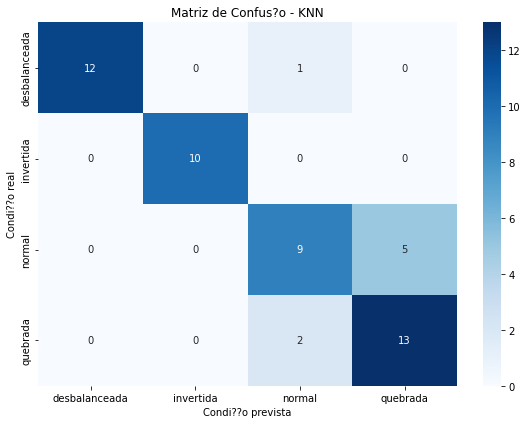

Features salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_features.csv
Nomes das features salvos em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_feature_names.txt
M?tricas salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_metrics.txt
M?tricas em CSV salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_metrics.csv

Modelo salvo em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_bestModel.pkl


In [17]:
features = extract_features(window_length=50)
best_model = train_knn(features)
joblib.dump(best_model, MODEL_PATH)
print(f"\nModelo salvo em: {MODEL_PATH}")

## 4. Montagem da base final

A coluna `condicao` e o rotulo que o KNN deve prever. A coluna `arquivo` sera usada apenas para garantir que a validacao respeite a origem dos dados.

In [18]:
def save_training_artifacts(df_features, feature_names, metrics, classification_text, best_params):
    df_features.to_csv(FEATURES_PATH, index=False)

    with open(FEATURE_NAMES_PATH, "w", encoding="utf-8") as file:
        for name in feature_names:
            file.write(f"{name}\n")

    pd.DataFrame([metrics]).to_csv(METRICS_CSV_PATH, index=False)

    with open(METRICS_TXT_PATH, "w", encoding="utf-8") as file:
        file.write("=== Melhor KNN ===\n")
        for key, value in best_params.items():
            file.write(f"{key}: {value}\n")

        file.write("\n=== Metricas principais ===\n")
        for key, value in metrics.items():
            if isinstance(value, float):
                file.write(f"{key}: {value:.4f}\n")
            else:
                file.write(f"{key}: {value}\n")

        file.write("\n=== Relatorio de classificacao ===\n")
        file.write(classification_text)

    print(f"Features salvas em: {FEATURES_PATH}")
    print(f"Nomes das features salvos em: {FEATURE_NAMES_PATH}")
    print(f"M?tricas salvas em: {METRICS_TXT_PATH}")
    print(f"M?tricas em CSV salvas em: {METRICS_CSV_PATH}")

## 5. Separacao entre features, rotulos e grupos

- `X`: estatisticas usadas pelo modelo.
- `y`: condicao da helice.
- `groups`: nome do arquivo original, usado na validacao cruzada agrupada.

In [19]:
def train_knn(df_features):
    X = df_features.drop(columns=["condicao"])
    y = df_features["condicao"]

    X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.4,
        random_state=42,
        stratify=y,
    )

    pipeline = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier()),
        ]
    )

    param_grid = {
        "knn__n_neighbors": [1, 3, 5, 7],
        "knn__weights": ["uniform", "distance"],
        "knn__metric": ["euclidean", "manhattan"],
    }

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        cv=3,
        scoring="accuracy",
        n_jobs=-1,
    )

    grid_search.fit(X_train, y_train)

    print("\n=== Dataset extra?do ===")
    print(f"Total de janelas: {len(df_features)}")
    print("Janelas por classe:")
    print(y.value_counts())

    print("\n=== Melhor KNN ===")
    print("Melhores hiperpar?metros:", grid_search.best_params_)
    print("Melhor acur?cia m?dia:", grid_search.best_score_)

    y_pred = grid_search.predict(X_test)
    y_proba = grid_search.predict_proba(X_test)

    print("\n=== Relat?rio no conjunto de teste ===")
    report = classification_report(y_test, y_pred, zero_division=0)
    print(report)

    labels = grid_search.best_estimator_.classes_

    accuracy = accuracy_score(y_test, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average="macro", zero_division=0)
    roc_auc_macro = roc_auc_score(
        y_test,
        y_proba,
        labels=labels,
        multi_class="ovr",
        average="macro",
    )

    print("\n=== M?tricas principais ===")
    print(f"Acur?cia: {accuracy:.4f}")
    print(f"Balanced accuracy: {balanced_accuracy:.4f}")
    print(f"Precis?o macro: {precision_macro:.4f}")
    print(f"Recall macro: {recall_macro:.4f}")
    print(f"F1-score macro: {f1_macro:.4f}")
    print(f"ROC-AUC macro OvR: {roc_auc_macro:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.title("Matriz de Confus?o - KNN")
    plt.ylabel("Condi??o real")
    plt.xlabel("Condi??o prevista")
    plt.tight_layout()
    plt.savefig(CONFUSION_MATRIX_PATH, dpi=300)
    if ARTICLE_CONFUSION_MATRIX_PATH.parent.exists():
        plt.savefig(ARTICLE_CONFUSION_MATRIX_PATH, dpi=300)
    plt.show()

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "roc_auc_macro_ovr": roc_auc_macro,
        "best_cv_accuracy": grid_search.best_score_,
        "total_windows": len(df_features),
        "train_windows": len(X_train),
        "test_windows": len(X_test),
    }

    save_training_artifacts(
        df_features=df_features,
        feature_names=X_train.columns,
        metrics=metrics,
        classification_text=report,
        best_params=grid_search.best_params_,
    )

    return grid_search.best_estimator_

## 6. Pipeline do KNN

O `StandardScaler` e necessario porque o KNN depende de distancia. Sem normalizacao, variaveis com escala maior dominam o calculo de vizinhanca.


================== normal ==================
Arquivos encontrados: 4

================== desbalanceada ==================
Arquivos encontrados: 4

================== quebrada ==================
Arquivos encontrados: 5

================== invertida ==================
Arquivos encontrados: 3

=== Dataset extra?do ===
Total de janelas: 130
Janelas por classe:
quebrada         38
normal           34
desbalanceada    33
invertida        25
Name: condicao, dtype: int64

=== Melhor KNN ===
Melhores hiperpar?metros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 1, 'knn__weights': 'uniform'}
Melhor acur?cia m?dia: 0.8846153846153846

=== Relat?rio no conjunto de teste ===
               precision    recall  f1-score   support

desbalanceada       1.00      0.92      0.96        13
    invertida       1.00      1.00      1.00        10
       normal       0.75      0.64      0.69        14
     quebrada       0.72      0.87      0.79        15

     accuracy                           0.85   

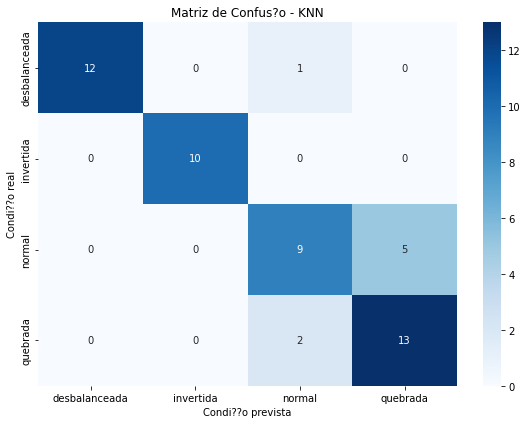

Features salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_features.csv
Nomes das features salvos em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_feature_names.txt
M?tricas salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_metrics.txt
M?tricas em CSV salvas em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_metrics.csv

Modelo salvo em: C:\Users\User\Downloads\MachineLearning_Trabalho1-main (2)\MachineLearning_Trabalho1-main\Trabalho_2\KNN_bestModel.pkl


In [20]:
features = extract_features(window_length=50)
best_model = train_knn(features)
joblib.dump(best_model, MODEL_PATH)
print(f"\nModelo salvo em: {MODEL_PATH}")